In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# =========================
# CONFIG
# =========================
TS = 0.07
TIME_STEPS = 20
BATCH_SIZE = 32
EPOCHS = 20

DATA_PATH = "./Data/Datasets.xlsx"

TARGET_NAME = "Y"
PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm", "sinTheta"]

TITLES = ["Train_1", "Train_2", "Val_1", "Val_2", "Test_1", "Test_2", "LSG_1", "LSG_2"]


In [8]:
# =========================
# LOAD TREINO
# =========================
df = pd.concat([pd.read_excel(DATA_PATH, sheet_name="Train_1"),
               pd.read_excel(DATA_PATH, sheet_name="Train_2")])

Target = df[TARGET_NAME].values
dTarget = df[f"d{TARGET_NAME}"].values

pred_raw = df[PREDICTORS].values

# =========================
# NORMALIZAÇÃO
# =========================
pred_mean = pred_raw.mean(axis=0)
pred_std = pred_raw.std(axis=0) + 1e-8
pred_raw = (pred_raw - pred_mean) / pred_std

y_mean = dTarget.mean()
y_std = dTarget.std() + 1e-8
y_raw = (dTarget - y_mean) / y_std

# =========================
# SLIDING WINDOW
# =========================
def create_sequences(pred, target, time_steps):
    Xs, ys = [], []
    for i in range(len(pred) - time_steps):
        Xs.append(pred[i:i+time_steps])
        ys.append(target[i+time_steps])
    return np.array(Xs), np.array(ys)

X, y = create_sequences(pred_raw, y_raw, TIME_STEPS)

# =========================
# MODELO (dinâmico)
# =========================
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(TIME_STEPS, len(PREDICTORS))),
    tf.keras.layers.SimpleRNN(32, activation='tanh'),
    tf.keras.layers.Dense(1, activation='linear')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse'
)

# =========================
# TREINO
# =========================
model.fit(X, y, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2)


Epoch 1/20
49/49 [==============================] - 3s 13ms/step - loss: 0.4755 - val_loss: 0.1721
Epoch 2/20
49/49 [==============================] - 0s 7ms/step - loss: 0.1089 - val_loss: 0.0890
Epoch 3/20
49/49 [==============================] - 0s 9ms/step - loss: 0.0490 - val_loss: 0.0589
Epoch 4/20
49/49 [==============================] - 0s 6ms/step - loss: 0.0293 - val_loss: 0.0474
Epoch 5/20
49/49 [==============================] - 0s 6ms/step - loss: 0.0228 - val_loss: 0.0421
Epoch 6/20
49/49 [==============================] - 0s 6ms/step - loss: 0.0200 - val_loss: 0.0366
Epoch 7/20
49/49 [==============================] - 0s 6ms/step - loss: 0.0175 - val_loss: 0.0365
Epoch 8/20
49/49 [==============================] - 0s 7ms/step - loss: 0.0159 - val_loss: 0.0365
Epoch 9/20
49/49 [==============================] - 0s 5ms/step - loss: 0.0141 - val_loss: 0.0329
Epoch 10/20
49/49 [==============================] - 0s 5ms/step - loss: 0.0133 - val_loss: 0.0310
Epoch 11/20
49/49 

Train_1 | R2 dtarget: 0.9789 | R2 Theta: 0.9873
Train_2 | R2 dtarget: 0.9889 | R2 Theta: 0.9942
Val_1 | R2 dtarget: 0.9772 | R2 Theta: 0.9930
Val_2 | R2 dtarget: 0.9786 | R2 Theta: 0.9877
Test_1 | R2 dtarget: 0.6792 | R2 Theta: -0.5052
Test_2 | R2 dtarget: 0.8120 | R2 Theta: -0.1063
LSG_1 | R2 dtarget: 0.3771 | R2 Theta: -2.2915
LSG_2 | R2 dtarget: 0.3922 | R2 Theta: -0.9546


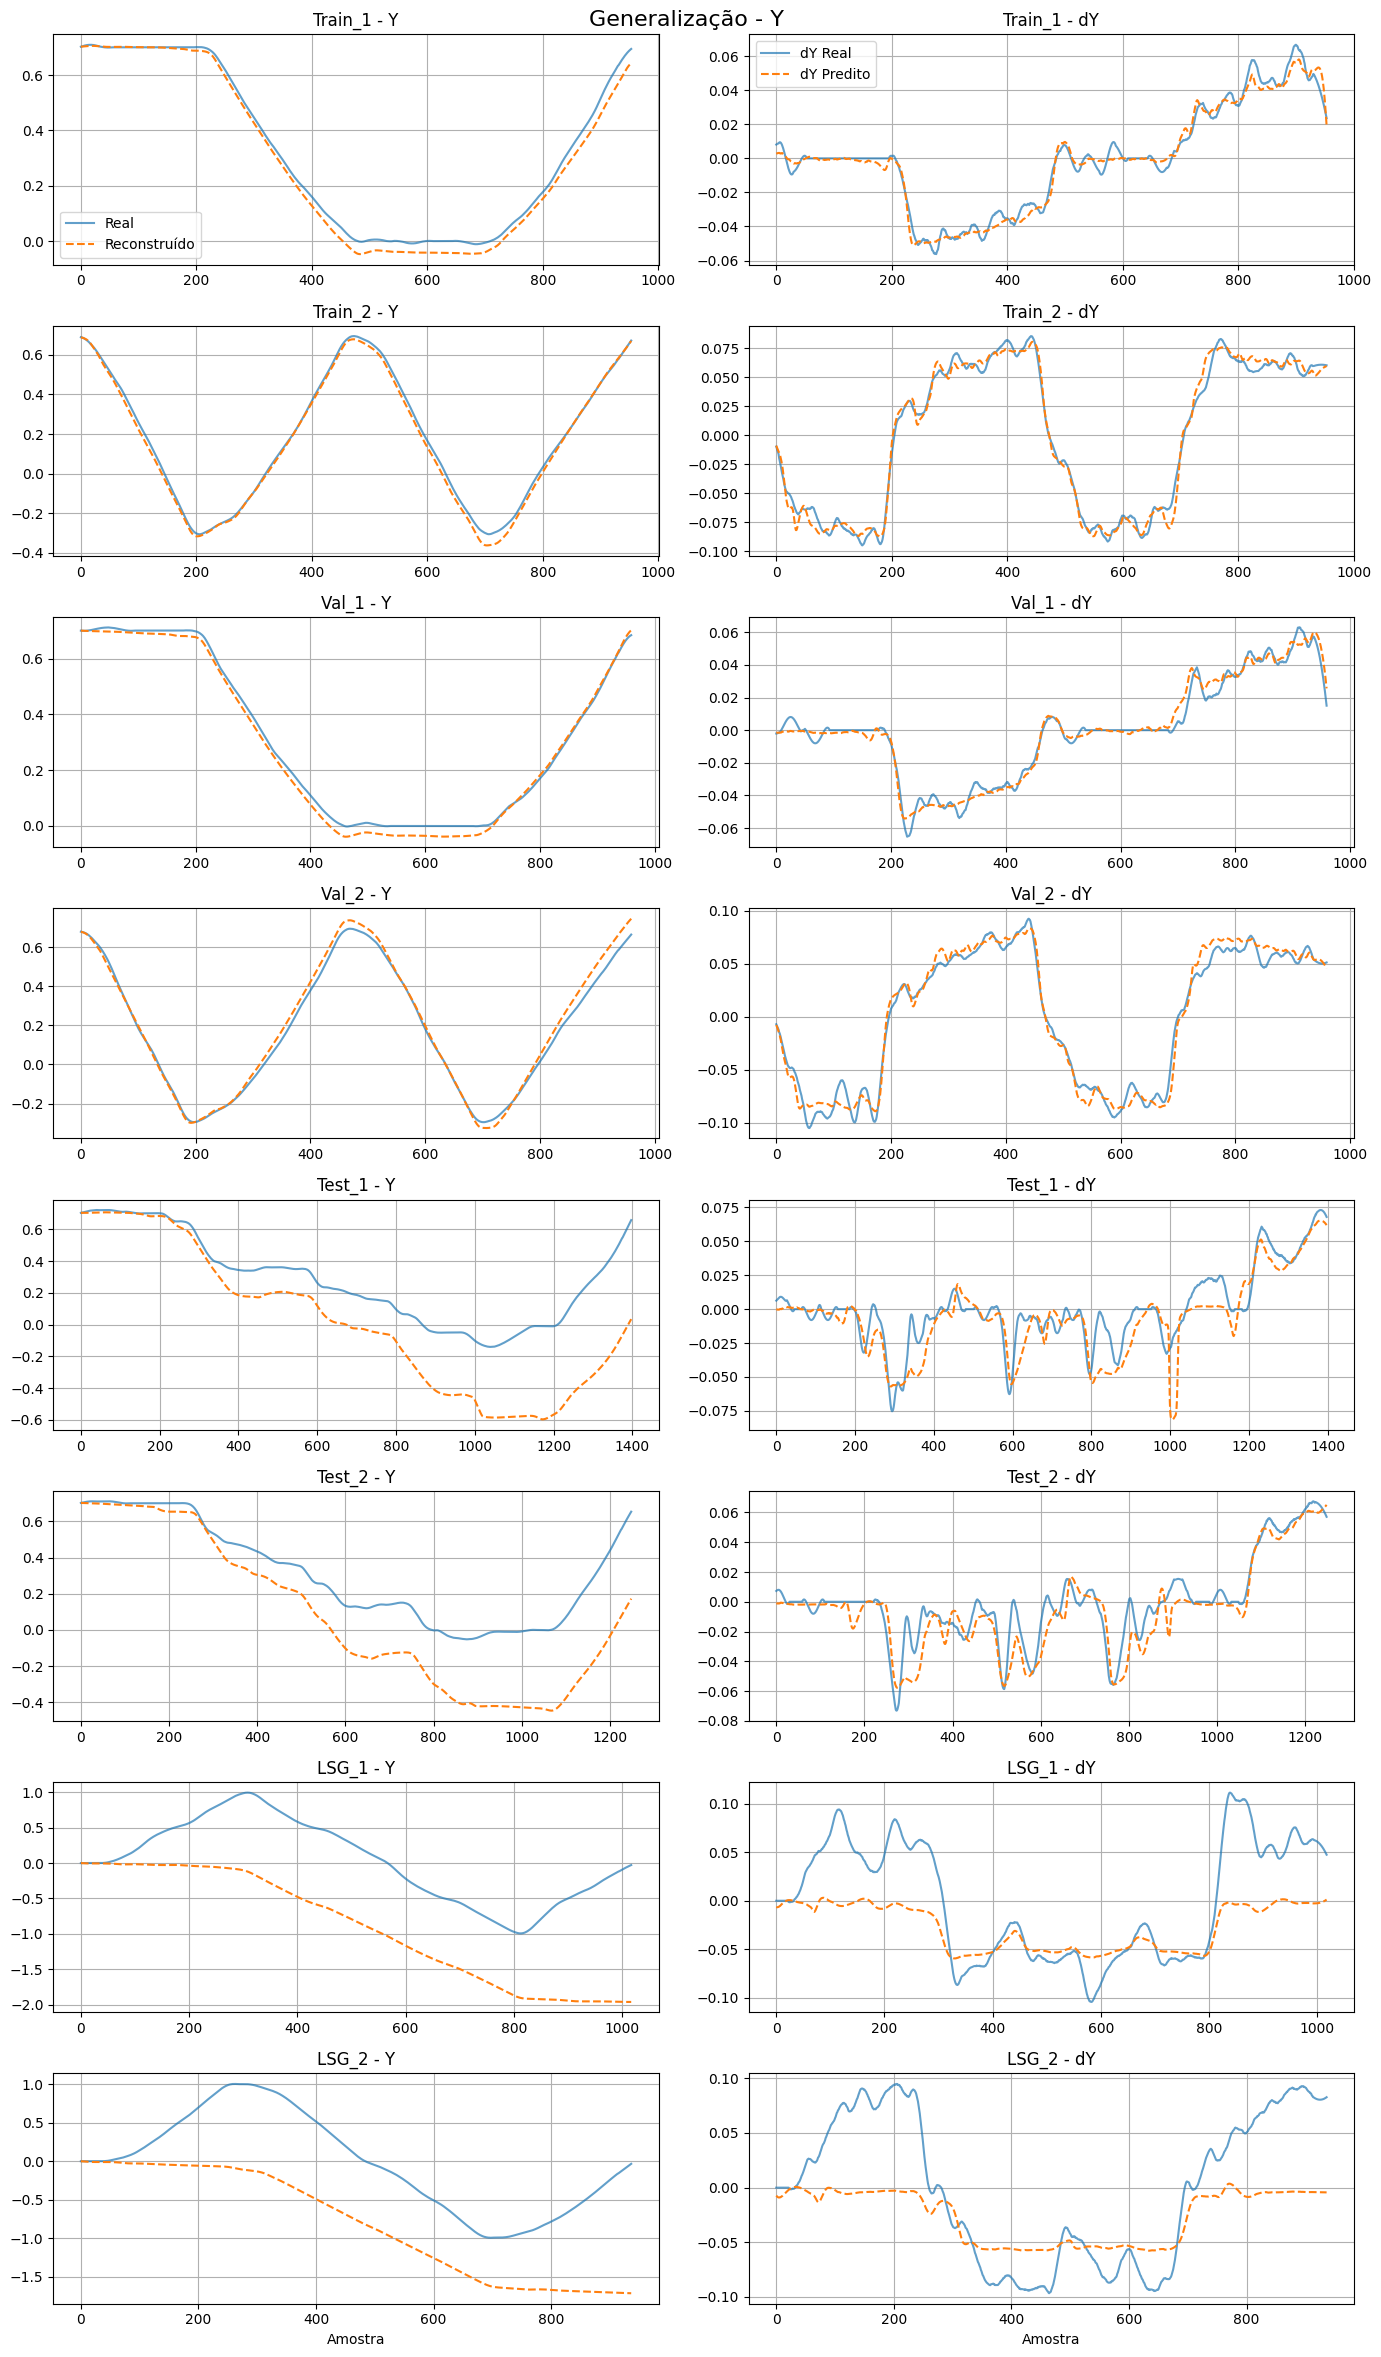

In [9]:
# =========================
# Teste
# =========================
n = len(TITLES)
fig, axs = plt.subplots(n, 2, figsize=(14, 3*n))

for i, title in enumerate(TITLES):

    df = pd.read_excel(DATA_PATH, sheet_name=title)

    Target = df[TARGET_NAME].values
    dTarget = df[f"d{TARGET_NAME}"].values

    pred_raw = df[PREDICTORS].values

    # normalização treino
    pred_raw = (pred_raw - pred_mean) / pred_std
    y_raw = (dTarget - y_mean) / y_std

    X_test, y_test = create_sequences(pred_raw, y_raw, TIME_STEPS)

    # predição
    y_pred = model.predict(X_test, verbose=0)

    y_pred = y_pred * y_std + y_mean
    y_true = y_test * y_std + y_mean

    # =========================
    # RECONSTRUÇÃO 
    # =========================
    Target_true = Target[TIME_STEPS:]
    Target_rec = np.zeros_like(y_pred.flatten())
    y_pred_flat = y_pred.flatten()
    Target_rec = Target_true[0] + np.cumsum(y_pred_flat * TS)


    # =========================
    # PLOT TARGET
    # =========================
    axs[i, 0].plot(Target_true, label="Real", alpha=0.7)
    axs[i, 0].plot(Target_rec, label="Reconstruído", linestyle='--')

    axs[i, 0].set_title(f"{title} - {TARGET_NAME}")
    axs[i, 0].grid(True)

    if i == 0:
        axs[i, 0].legend()

    # =========================
    # PLOT DERIVADA
    # =========================
    axs[i, 1].plot(y_true, label=f"d{TARGET_NAME} Real", alpha=0.7)
    axs[i, 1].plot(y_pred, label=f"d{TARGET_NAME} Predito", linestyle='--')

    axs[i, 1].set_title(f"{title} - d{TARGET_NAME}")
    axs[i, 1].grid(True)

    if i == 0:
        axs[i, 1].legend()
    r2_dtarget = r2_score(y_true.flatten(), y_pred.flatten())
    r2_target  = r2_score(Target_true.flatten(), Target_rec.flatten())
    print(f"{title} | R2 dtarget: {r2_dtarget:.4f} | R2 Theta: {r2_target:.4f}")

axs[-1, 0].set_xlabel("Amostra")
axs[-1, 1].set_xlabel("Amostra")

plt.suptitle(f"Generalização - {TARGET_NAME}", fontsize=16)
plt.tight_layout()
plt.show()